# Correlation Analysis

Correlation measures the **strength and direction** of the linear (or monotonic) relationship between two variables.

| Measure | Type | When to use |
|---------|------|-------------|
| Pearson's r | Parametric | Both variables continuous, approximately normal, linear relationship |
| Spearman's ρ | Non-parametric | Ordinal data, non-linear but monotonic, outliers present |
| Kendall's τ | Non-parametric | Small samples, many ties |

**Range:** $-1 \leq r \leq 1$ where $\pm 1$ = perfect correlation, $0$ = no linear relationship.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)
n   = 80

# Simulate: study hours, exam score (strong positive), sleep hours (weak negative), random noise
study_hours = rng.uniform(1, 10, size=n)
exam_score  = 40 + 5.5 * study_hours + rng.normal(0, 8, size=n)
sleep_hours = 8 - 0.3 * study_hours + rng.normal(0, 1.5, size=n)
noise       = rng.normal(0, 1, size=n)

df = pd.DataFrame({'study_hours': study_hours,
                   'exam_score' : exam_score.clip(0, 100),
                   'sleep_hours': sleep_hours.clip(4, 12),
                   'random'     : noise})

print('Pearson Correlations with exam_score:')
for col in ['study_hours', 'sleep_hours', 'random']:
    r, p = stats.pearsonr(df['exam_score'], df[col])
    print(f'  {col:<15}: r={r:+.3f}, p={p:.4f}')


Pearson Correlations with exam_score:
  study_hours    : r=+0.889, p=0.0000
  sleep_hours    : r=-0.580, p=0.0000
  random         : r=-0.173, p=0.1240


## Pearson vs Spearman — Sensitivity to Outliers

In [2]:
# Add a single outlier and compare both measures
x_clean  = rng.normal(50, 10, size=30)
y_clean  = x_clean + rng.normal(0, 5, size=30)

x_out = np.append(x_clean, 200)   # extreme outlier
y_out = np.append(y_clean, 10)

r_clean,  _ = stats.pearsonr(x_clean, y_clean)
rho_clean,_ = stats.spearmanr(x_clean, y_clean)
r_out,    _ = stats.pearsonr(x_out, y_out)
rho_out,  _ = stats.spearmanr(x_out, y_out)

print('Effect of one outlier on correlation:')
print(f'            Clean data    After outlier')
print(f'Pearson r : {r_clean:+.4f}        {r_out:+.4f}')
print(f'Spearman r: {rho_clean:+.4f}        {rho_out:+.4f}')
print()
print('Spearman (rank-based) is far more robust to the outlier.')


Effect of one outlier on correlation:
            Clean data    After outlier
Pearson r : +0.9048        -0.2487
Spearman r: +0.8928        +0.7153

Spearman (rank-based) is far more robust to the outlier.


## Correlation Matrix Heatmap

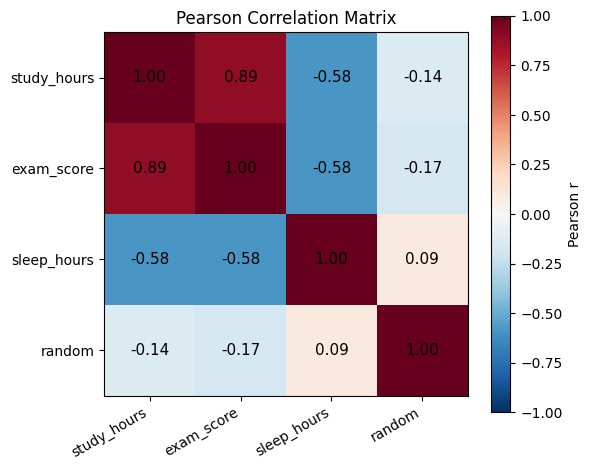

In [3]:
corr = df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='black')
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()


## Correlation ≠ Causation: Anscombe's Quartet

All four datasets below have **identical summary statistics** (mean, variance, correlation, regression line) yet are structurally completely different. Always visualise before computing correlations.

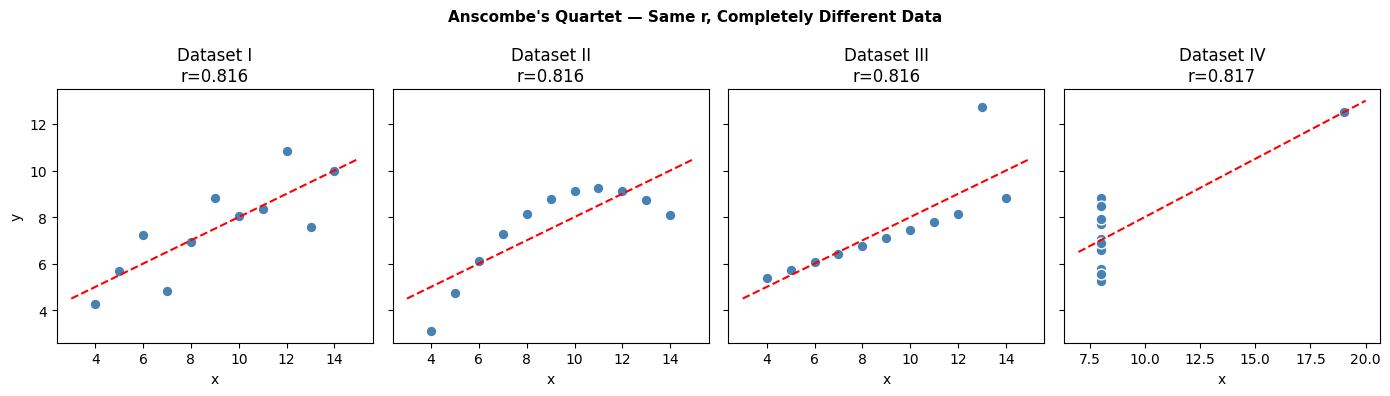

In [4]:
# Anscombe's Quartet
x1 = [10,8,13,9,11,14,6,4,12,7,5]
x2 = x1
x3 = x1
x4 = [8,8,8,8,8,8,8,19,8,8,8]
y1 = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]
y2 = [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]
y3 = [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]
y4 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, x, y, label in zip(axes,
                            [x1,x2,x3,x4], [y1,y2,y3,y4],
                            ['I','II','III','IV']):
    ax.scatter(x, y, color='steelblue', edgecolor='white', s=60)
    m, b, r, *_ = stats.linregress(x, y)
    xs = np.linspace(min(x)-1, max(x)+1, 100)
    ax.plot(xs, m*xs+b, 'r--', lw=1.5)
    ax.set_title(f'Dataset {label}\nr={r:.3f}')
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle("Anscombe's Quartet — Same r, Completely Different Data",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ML/AI Connection

- **Multicollinearity detection:** highly correlated features ($|r| > 0.9$) in linear/logistic regression inflate coefficient variance — use VIF or drop one of the pair.
- **PCA** finds principal components that are uncorrelated linear combinations of the original features — it diagonalises the covariance (correlation) matrix.
- **Feature selection:** correlation with target (`df.corr()['target']`) provides a fast filter-method feature importance baseline.
- **Anscombe's Quartet** is the canonical argument for *always plotting* data before modelling — same correlation, wildly different structure.
